# Level 2 - Task 2
## Cuisine Combination Analysis

### task
- Identify the most common combinations of cuisines.
- Determine whether certain cuisine combinations tend to have higher ratings.
  
**Prepared By:** Suraj 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Dataset .csv")

In [3]:
cuisine_combinations = (
    df["Cuisines"]
    .dropna()
    .value_counts()
)

cuisine_combinations.head(10)

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

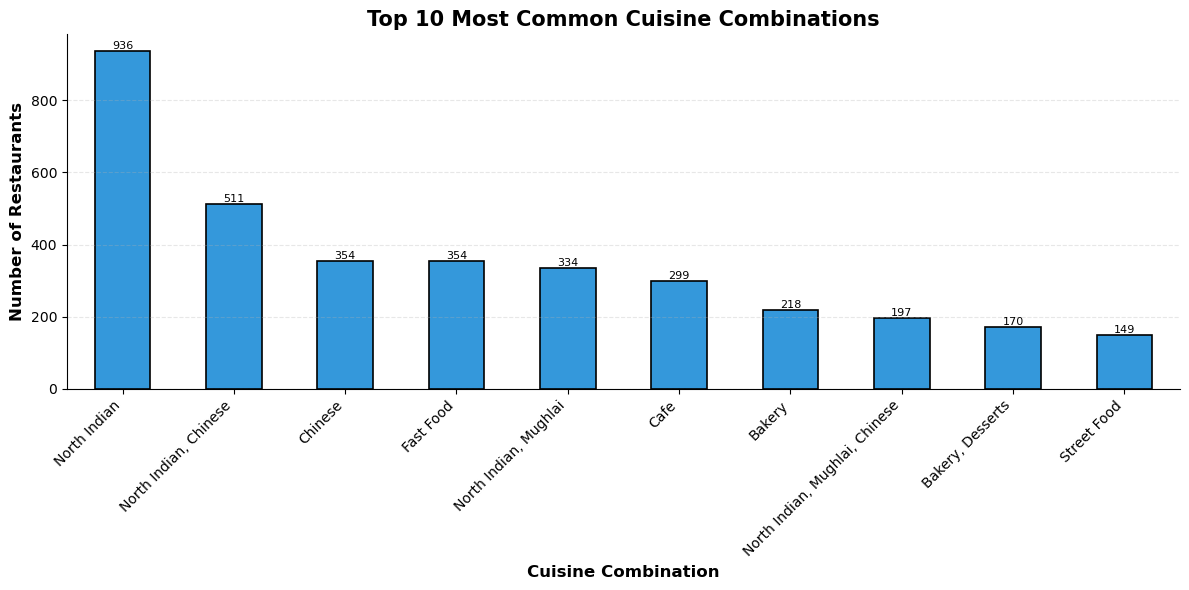

In [4]:
# Top 10 Cuisine Combinations

top10_combination = cuisine_combinations.head(10)

plt.figure(figsize=(12,6))

ax = top10_combination.plot(
    kind="bar",
    color="#3498DB",
    edgecolor="black",
    linewidth=1.2
)

plt.title(
    "Top 10 Most Common Cuisine Combinations",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Cuisine Combination", fontsize=12, fontweight="bold")
plt.ylabel("Number of Restaurants", fontsize=12, fontweight="bold")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.3)

# Remove Borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Data Labels
for bar in ax.patches:
    ax.annotate(
        f"{int(bar.get_height())}",
        (bar.get_x()+bar.get_width()/2,
         bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [5]:
# Average Rating by Cuisine Combination

cuisine_rating = (
    df.groupby("Cuisines")["Aggregate rating"]
      .mean()
      .sort_values(ascending=False)
)

cuisine_rating.head(10)

Cuisines
Italian, Deli               4.9
Hawaiian, Seafood           4.9
American, Sandwich, Tea     4.9
Continental, Indian         4.9
European, Asian, Indian     4.9
European, Contemporary      4.9
European, German            4.9
BBQ, Breakfast, Southern    4.9
American, Coffee and Tea    4.9
Sunda, Indonesian           4.9
Name: Aggregate rating, dtype: float64

In [6]:
# Cuisine Summary (Count + Average Rating)

cuisine_summary = (
    df.groupby("Cuisines")
      .agg(
          Total_Restaurants=("Restaurant ID", "count"),
          Average_Rating=("Aggregate rating", "mean")
      )
)

cuisine_summary.head()

,Total_Restaurants,Average_Rating
Cuisines,,
Afghani,4,0.725
"Afghani, Mughlai, Chinese",1,0.000
"Afghani, North Indian",1,0.000
"Afghani, North Indian, Pakistani, Arabian",1,0.000
African,1,4.700


In [7]:
# Keep Only Popular Cuisine Combinations

popular_cuisine = cuisine_summary[
    cuisine_summary["Total_Restaurants"] >= 10
]

popular_cuisine.sort_values(
    by="Average_Rating",
    ascending=False
).head(10)

,Total_Restaurants,Average_Rating
Cuisines,,
Modern Indian,11,4.345455
Indian,18,4.250000
Seafood,14,4.114286
Thai,16,4.100000
"Cafe, Continental, Italian",10,4.080000
"American, Burger",13,4.076923
"Japanese, Sushi",18,4.044444
"Pizza, Italian",19,3.668421
American,31,3.667742


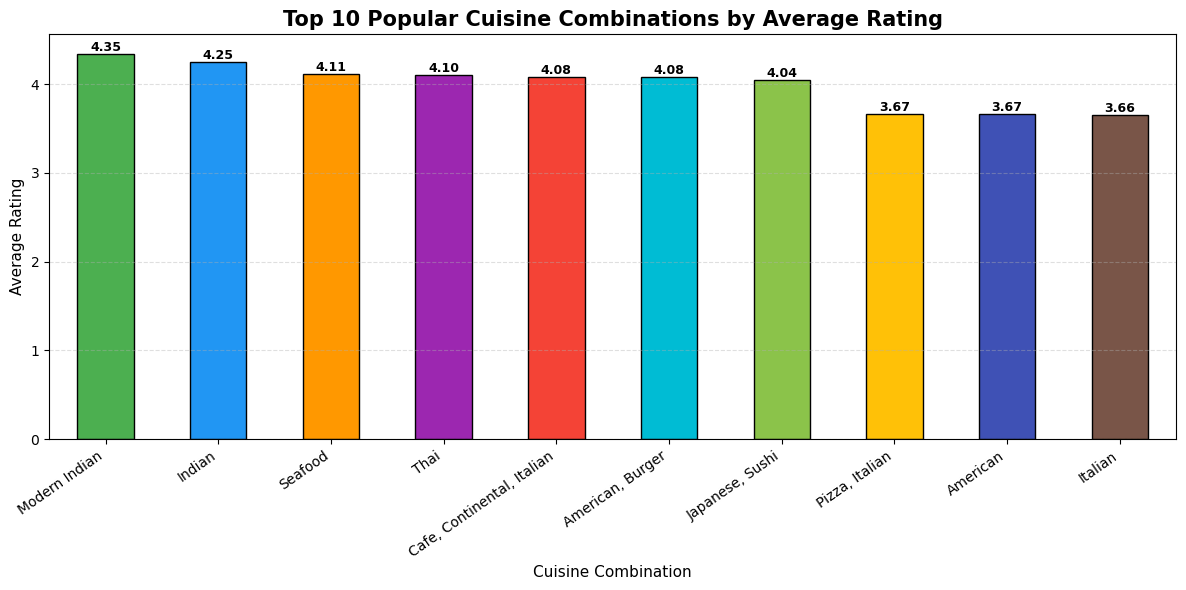

In [8]:
# Top 10 Cuisine Combinations by Average Rating

top10 = popular_cuisine.sort_values(
    by="Average_Rating",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

ax = top10["Average_Rating"].plot(
    kind="bar",
    color=[
        "#4CAF50","#2196F3","#FF9800","#9C27B0","#F44336",
        "#00BCD4","#8BC34A","#FFC107","#3F51B5","#795548"
    ],
    edgecolor="black",
    linewidth=1
)

plt.title(
    "Top 10 Popular Cuisine Combinations by Average Rating",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Cuisine Combination", fontsize=11)
plt.ylabel("Average Rating", fontsize=11)

plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Data Labels
for bar in ax.patches:
    ax.annotate(
        f"{bar.get_height():.2f}",
        (bar.get_x()+bar.get_width()/2, bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

## Insights

• Modern Indian cuisine has the highest average rating (4.34) among popular cuisine combinations.

• Indian cuisine ranks second with an average rating of 4.25.

• Seafood and Thai cuisines also receive consistently high customer ratings.

• Cafe, Continental, Italian and American, Burger combinations are among the top-rated multi-cuisine offerings.

• Popular cuisine combinations generally maintain ratings above 4.0, indicating strong customer satisfaction.

## Conclusion

Cuisine combinations have a significant impact on restaurant ratings. Modern Indian and Indian cuisines perform exceptionally well, while several multi-cuisine combinations also receive high customer ratings. Restaurants offering these cuisines tend to achieve better customer satisfaction.